In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

telo = pd.read_sas(DATA_DIR / "TELO_A.xpt", format="xport")
demo = pd.read_sas(DATA_DIR / "DEMO.xpt", format="xport")
bmx  = pd.read_sas(DATA_DIR / "BMX.xpt", format="xport")
smq  = pd.read_sas(DATA_DIR / "SMQ.xpt", format="xport")
paq  = pd.read_sas(DATA_DIR / "PAQ.xpt", format="xport")
alq  = pd.read_sas(DATA_DIR / "ALQ.xpt", format="xport")

In [3]:
df = telo.merge(demo, on="SEQN", how="left")
df = df.merge(bmx, on="SEQN", how="left")
df = df.merge(smq, on="SEQN", how="left")
df = df.merge(paq, on="SEQN", how="left")
df = df.merge(alq, on="SEQN", how="left")
df.shape

(3570, 249)

In [4]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR"]
df_model = df[cols].copy()
df_model = df_model.dropna()
df_model.shape

(3567, 3)

In [5]:
X = df_model[["RIDAGEYR"]]
y = df_model["TELOMEAN"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 2853
Testing rows: 714


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.1392391894802829
MAE: 0.19360927077083298
RMSE: 0.25015063174272023


In [7]:
df_model["TELOMEAN"].describe()

count    3567.000000
mean        0.998350
std         0.296396
min         0.389337
25%         0.807936
50%         0.964025
75%         1.148191
max         9.420415
Name: TELOMEAN, dtype: float64

In [8]:
df_model["TELOMEAN"].sort_values(ascending=False).head(10)

3569    9.420415
3568    3.315313
3567    2.515980
3566    2.310322
3565    2.225661
3564    2.186959
3563    2.186498
3562    2.109059
3561    2.105013
3560    2.021131
Name: TELOMEAN, dtype: float64

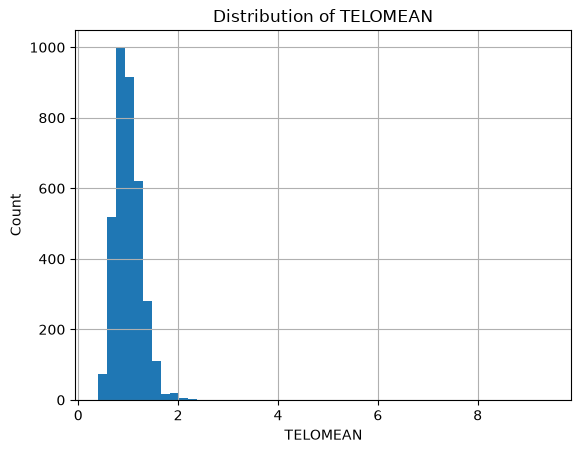

In [9]:
import matplotlib.pyplot as plt

df_model["TELOMEAN"].hist(bins=50)
plt.xlabel("TELOMEAN")
plt.ylabel("Count")
plt.title("Distribution of TELOMEAN")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

print("Random Forest  R²:", r2_score(y_test, rf_predictions))
print("Gradient Boost R²:", r2_score(y_test, gb_predictions))
print("Linear Reg     R²:", r2)  # from your earlier cell, for comparison

Random Forest  R²: 0.12038125309309966
Gradient Boost R²: 0.12411260386053236
Linear Reg     R²: 0.1392391894802829


In [11]:
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42), X_train, y_train, cv=5, scoring="r2")
gb_cv = cross_val_score(GradientBoostingRegressor(random_state=42), X_train, y_train, cv=5, scoring="r2")

print("Linear Regression CV R²:", lr_cv.mean(), "+/-", lr_cv.std())
print("Random Forest CV R²:    ", rf_cv.mean(), "+/-", rf_cv.std())
print("Gradient Boosting CV R²:", gb_cv.mean(), "+/-", gb_cv.std())

Linear Regression CV R²: 0.14061333904485582 +/- 0.031244011645637573
Random Forest CV R²:     0.10689251047873924 +/- 0.02490094127690209
Gradient Boosting CV R²: 0.11859207390057332 +/- 0.025335827280594105


In [12]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR"]
df_model2 = df[cols].copy()
df_model2 = df_model2.dropna()

# encode sex: 1=Male -> 0, 2=Female -> 1
df_model2["sex_female"] = (df_model2["RIAGENDR"] == 2).astype(int)

df_model2.shape

(3567, 5)

In [13]:
X2 = df_model2[["RIDAGEYR", "sex_female"]]
y2 = df_model2["TELOMEAN"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

lr2 = LinearRegression().fit(X2_train, y2_train)
rf2 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X2_train, y2_train)
gb2 = GradientBoostingRegressor(random_state=42).fit(X2_train, y2_train)

print("Linear Regression R²:", r2_score(y2_test, lr2.predict(X2_test)))
print("Random Forest R²:    ", r2_score(y2_test, rf2.predict(X2_test)))
print("Gradient Boosting R²:", r2_score(y2_test, gb2.predict(X2_test)))

Linear Regression R²: 0.13928704068513453
Random Forest R²:     0.10231817562304246
Gradient Boosting R²: 0.1196046489498318


In [14]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1"]
df_model3 = df[cols].copy()
df_model3 = df_model3.dropna()

df_model3["sex_female"] = (df_model3["RIAGENDR"] == 2).astype(int)

df_model3 = pd.get_dummies(df_model3, columns=["RIDRETH1"], prefix="race", drop_first=True)

df_model3.head()

,SEQN,TELOMEAN,RIDAGEYR,RIAGENDR,sex_female,race_2.0,race_3.0,race_4.0,race_5.0
3,2084.0,0.389337,76.0,1.0,0,False,False,True,False
4,6445.0,0.433244,81.0,1.0,0,False,True,False,False
5,5363.0,0.443293,81.0,1.0,0,False,True,False,False
6,8606.0,0.444447,78.0,1.0,0,False,True,False,False
7,8468.0,0.449683,85.0,1.0,0,False,True,False,False


In [15]:
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
X3 = df_model3[["RIDAGEYR", "sex_female"] + race_cols]
y3 = df_model3["TELOMEAN"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

lr3 = LinearRegression().fit(X3_train, y3_train)
rf3 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X3_train, y3_train)
gb3 = GradientBoostingRegressor(random_state=42).fit(X3_train, y3_train)

print("Linear Regression R²:", r2_score(y3_test, lr3.predict(X3_test)))
print("Random Forest R²:    ", r2_score(y3_test, rf3.predict(X3_test)))
print("Gradient Boosting R²:", r2_score(y3_test, gb3.predict(X3_test)))

Linear Regression R²: 0.15781781618450763
Random Forest R²:     -0.07188010086625418
Gradient Boosting R²: 0.13204029153008334


In [16]:
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
X3 = df_model3[["RIDAGEYR", "sex_female"] + race_cols]
y3 = df_model3["TELOMEAN"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

lr3 = LinearRegression().fit(X3_train, y3_train)
rf3 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X3_train, y3_train)
gb3 = GradientBoostingRegressor(random_state=42).fit(X3_train, y3_train)

print("Linear Regression R²:", r2_score(y3_test, lr3.predict(X3_test)))
print("Random Forest R²:    ", r2_score(y3_test, rf3.predict(X3_test)))
print("Gradient Boosting R²:", r2_score(y3_test, gb3.predict(X3_test)))

Linear Regression R²: 0.15781781618450763
Random Forest R²:     -0.07188010086625418
Gradient Boosting R²: 0.13204029153008334


In [17]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]
df_model4 = df[cols].copy()
df_model4 = df_model4.dropna()

df_model4["sex_female"] = (df_model4["RIAGENDR"] == 2).astype(int)
df_model4 = pd.get_dummies(df_model4, columns=["RIDRETH1"], prefix="race", drop_first=True)

df_model4.shape

(3531, 10)

In [18]:
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
X4 = df_model4[["RIDAGEYR", "sex_female", "BMXBMI"] + race_cols]
y4 = df_model4["TELOMEAN"]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)

lr4 = LinearRegression().fit(X4_train, y4_train)
rf4 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X4_train, y4_train)
gb4 = GradientBoostingRegressor(random_state=42).fit(X4_train, y4_train)

print("Linear Regression R²:", r2_score(y4_test, lr4.predict(X4_test)))
print("Random Forest R²:    ", r2_score(y4_test, rf4.predict(X4_test)))
print("Gradient Boosting R²:", r2_score(y4_test, gb4.predict(X4_test)))

Linear Regression R²: 0.07187907820191985
Random Forest R²:     0.022286358000184858
Gradient Boosting R²: 0.06581271566253033


In [19]:
df_model4["BMXBMI"].describe()

count    3531.000000
mean       28.446434
std         6.165158
min        15.160000
25%        24.160000
50%        27.500000
75%        31.630000
max        66.440000
Name: BMXBMI, dtype: float64

In [20]:
lr4_cv = cross_val_score(LinearRegression(), X4_train, y4_train, cv=5, scoring="r2")
rf4_cv = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42), X4_train, y4_train, cv=5, scoring="r2")
gb4_cv = cross_val_score(GradientBoostingRegressor(random_state=42), X4_train, y4_train, cv=5, scoring="r2")

print("Linear Regression CV R²:", lr4_cv.mean(), "+/-", lr4_cv.std())
print("Random Forest CV R²:    ", rf4_cv.mean(), "+/-", rf4_cv.std())
print("Gradient Boosting CV R²:", gb4_cv.mean(), "+/-", gb4_cv.std())

Linear Regression CV R²: 0.17521557259661985 +/- 0.007308071258641023
Random Forest CV R²:     0.030978700269237814 +/- 0.02621425018511264
Gradient Boosting CV R²: 0.155032565333115 +/- 0.010693734037730381


In [21]:
import numpy as np

cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "SMQ020"]
df_model5 = df[cols].copy()

# recode NHANES special code (7=refused) to NaN before dropping missing rows
df_model5["SMQ020"] = df_model5["SMQ020"].replace([7, 9], np.nan)

df_model5 = df_model5.dropna()

df_model5["sex_female"] = (df_model5["RIAGENDR"] == 2).astype(int)
df_model5 = pd.get_dummies(df_model5, columns=["RIDRETH1"], prefix="race", drop_first=True)

# recode smoking: 1=Yes smoked 100+ -> 1, 2=No -> 0
df_model5["ever_smoker"] = (df_model5["SMQ020"] == 1).astype(int)

df_model5.shape

(3523, 12)

In [22]:
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
X5 = df_model5[["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker"] + race_cols]
y5 = df_model5["TELOMEAN"]

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42
)

lr5 = LinearRegression().fit(X5_train, y5_train)
rf5 = RandomForestRegressor(n_estimators=300, random_state=42).fit(X5_train, y5_train)
gb5 = GradientBoostingRegressor(random_state=42).fit(X5_train, y5_train)

print("Linear Regression R²:", r2_score(y5_test, lr5.predict(X5_test)))
print("Random Forest R²:    ", r2_score(y5_test, rf5.predict(X5_test)))
print("Gradient Boosting R²:", r2_score(y5_test, gb5.predict(X5_test)))
lr5_cv = cross_val_score(LinearRegression(), X5_train, y5_train, cv=5, scoring="r2")
rf5_cv = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42), X5_train, y5_train, cv=5, scoring="r2")
gb5_cv = cross_val_score(GradientBoostingRegressor(random_state=42), X5_train, y5_train, cv=5, scoring="r2")

print("Linear Regression CV R²:", lr5_cv.mean(), "+/-", lr5_cv.std())
print("Random Forest CV R²:    ", rf5_cv.mean(), "+/-", rf5_cv.std())
print("Gradient Boosting CV R²:", gb5_cv.mean(), "+/-", gb5_cv.std())

Linear Regression R²: 0.15996643406249378
Random Forest R²:     -0.08401962032027854
Gradient Boosting R²: 0.05428170529134124
Linear Regression CV R²: 0.1463196254084505 +/- 0.0536157009594659
Random Forest CV R²:     -0.047291311835426675 +/- 0.09974837654670175
Gradient Boosting CV R²: 0.01884905197943214 +/- 0.14186254422456132


In [23]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI",
        "SMQ020", "PAD020", "ALQ120Q"]
df_full = df[cols].copy()

# recode NHANES special/missing codes to NaN before dropping rows
df_full["SMQ020"] = df_full["SMQ020"].replace([7, 9], np.nan)
df_full["PAD020"] = df_full["PAD020"].replace([7, 9], np.nan)
df_full["ALQ120Q"] = df_full["ALQ120Q"].replace([777, 999], np.nan)

df_full = df_full.dropna()

df_full["sex_female"] = (df_full["RIAGENDR"] == 2).astype(int)
df_full = pd.get_dummies(df_full, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_full["ever_smoker"] = (df_full["SMQ020"] == 1).astype(int)

df_full.shape

(2859, 14)

In [24]:
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
feature_cols = ["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker", "PAD020", "ALQ120Q"] + race_cols

X_full = df_full[feature_cols]
y_full = df_full["TELOMEAN"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

lr_full = LinearRegression().fit(Xf_train, yf_train)
rf_full = RandomForestRegressor(n_estimators=300, random_state=42).fit(Xf_train, yf_train)
gb_full = GradientBoostingRegressor(random_state=42).fit(Xf_train, yf_train)

print("Linear Regression R²:", r2_score(yf_test, lr_full.predict(Xf_test)))
print("Random Forest R²:    ", r2_score(yf_test, rf_full.predict(Xf_test)))
print("Gradient Boosting R²:", r2_score(yf_test, gb_full.predict(Xf_test)))
lr_full_cv = cross_val_score(LinearRegression(), Xf_train, yf_train, cv=5, scoring="r2")
rf_full_cv = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42), Xf_train, yf_train, cv=5, scoring="r2")
gb_full_cv = cross_val_score(GradientBoostingRegressor(random_state=42), Xf_train, yf_train, cv=5, scoring="r2")

print("Linear Regression CV R²:", lr_full_cv.mean(), "+/-", lr_full_cv.std())
print("Random Forest CV R²:    ", rf_full_cv.mean(), "+/-", rf_full_cv.std())
print("Gradient Boosting CV R²:", gb_full_cv.mean(), "+/-", gb_full_cv.std())

Linear Regression R²: 0.14328390220376908
Random Forest R²:     -0.014361386619136773
Gradient Boosting R²: 0.05238671802528816
Linear Regression CV R²: 0.15526492181215468 +/- 0.05470540411179131
Random Forest CV R²:     -0.055206357833731554 +/- 0.09522420124988157
Gradient Boosting CV R²: -0.2765697763154038 +/- 0.5234482941439212


In [25]:
rf_full_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,           # limits how deep each tree can grow
    min_samples_leaf=20,   # each final group needs at least 20 people
    random_state=42
)
gb_full_tuned = GradientBoostingRegressor(
    max_depth=3,            # gradient boosting trees are usually kept shallow
    min_samples_leaf=20,
    learning_rate=0.05,     # smaller steps = less likely to overfit
    n_estimators=200,
    random_state=42
)

rf_full_tuned.fit(Xf_train, yf_train)
gb_full_tuned.fit(Xf_train, yf_train)

print("Random Forest (tuned) R²:    ", r2_score(yf_test, rf_full_tuned.predict(Xf_test)))
print("Gradient Boosting (tuned) R²:", r2_score(yf_test, gb_full_tuned.predict(Xf_test)))
rf_tuned_cv = cross_val_score(rf_full_tuned, Xf_train, yf_train, cv=5, scoring="r2")
gb_tuned_cv = cross_val_score(gb_full_tuned, Xf_train, yf_train, cv=5, scoring="r2")

print("Random Forest (tuned) CV R²:    ", rf_tuned_cv.mean(), "+/-", rf_tuned_cv.std())
print("Gradient Boosting (tuned) CV R²:", gb_tuned_cv.mean(), "+/-", gb_tuned_cv.std())


Random Forest (tuned) R²:     0.13031974756878706
Gradient Boosting (tuned) R²: 0.11701484881510849
Random Forest (tuned) CV R²:     0.13557658322299254 +/- 0.0457482487763869
Gradient Boosting (tuned) CV R²: 0.10038756560500568 +/- 0.04445263480918989


In [26]:
def compare_models(X_train, y_train, label):
    lr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")

    rf = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
    rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")

    gb = GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42)
    gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2")

    print(f"--- {label} ---")
    print(f"Linear Regression CV R²: {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}")
    print(f"Random Forest CV R²:     {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
    print(f"Gradient Boosting CV R²: {gb_cv.mean():.3f} +/- {gb_cv.std():.3f}")
    print()

In [27]:
compare_models(X_train, y_train, "Age only")
compare_models(X2_train, y2_train, "Age + Sex")
compare_models(X3_train, y3_train, "Age + Sex + Race")
compare_models(X4_train, y4_train, "Age + Sex + Race + BMI")
compare_models(Xf_train, yf_train, "Full (all 7 variables)")

--- Age only ---
Linear Regression CV R²: 0.141 +/- 0.031
Random Forest CV R²:     0.122 +/- 0.026
Gradient Boosting CV R²: 0.119 +/- 0.026

--- Age + Sex ---
Linear Regression CV R²: 0.139 +/- 0.031
Random Forest CV R²:     0.126 +/- 0.026
Gradient Boosting CV R²: 0.120 +/- 0.025

--- Age + Sex + Race ---
Linear Regression CV R²: 0.151 +/- 0.037
Random Forest CV R²:     0.140 +/- 0.033
Gradient Boosting CV R²: 0.132 +/- 0.031

--- Age + Sex + Race + BMI ---
Linear Regression CV R²: 0.175 +/- 0.007
Random Forest CV R²:     0.165 +/- 0.009
Gradient Boosting CV R²: 0.158 +/- 0.002

--- Full (all 7 variables) ---
Linear Regression CV R²: 0.155 +/- 0.055
Random Forest CV R²:     0.136 +/- 0.046
Gradient Boosting CV R²: 0.100 +/- 0.044



In [28]:
feature_sets = {
    "Age": ["Age"],
    "Age + Sex": ["Age", "Sex"],
    "Age + Sex + Race": ["Age", "Sex", "Race"],
    "Age + Sex + Race + BMI": ["Age", "Sex", "Race", "BMI"],
    "Full": ["Age", "Sex", "Race", "BMI", "Variable5", "Variable6", "Variable7"]
}

all_results = []

for name, features in feature_sets.items():

    X = df[features]

    results = cross_validate(
        LinearRegression(),
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    all_results.append({
        "Model": name,
        "R2": results["test_R2"].mean(),
        "R2_SD": results["test_R2"].std(),
        "RMSE": -results["test_RMSE"].mean(),
        "RMSE_SD": -results["test_RMSE"].std(),
        "MAE": -results["test_MAE"].mean(),
        "MAE_SD": -results["test_MAE"].std()
    })

results_df = pd.DataFrame(all_results)

results_df

KeyError: "None of [Index(['Age'], dtype='str')] are in the [columns]"

In [ ]:
print(df.columns.tolist())

['SEQN', 'TELOMEAN', 'TELOSTD', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'RIDRETH2', 'DMQMILIT', 'DMDBORN', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDEDUC', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'INDHHINC', 'INDFMINC', 'INDFMPIR', 'RIDEXPRG', 'RIDPREG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBRN', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'WTINT2YR', 'WTINT4YR', 'WTMEC2YR', 'WTMEC4YR', 'SDMVPSU', 'SDMVSTRA', 'SDJ1REPN', 'DMAETHN', 'DMARACE', 'WTMREP01', 'WTMREP02', 'WTMREP03', 'WTMREP04', 'WTMREP05', 'WTMREP06', 'WTMREP07', 'WTMREP08', 'WTMREP09', 'WTMREP10', 'WTMREP11', 'WTMREP12', 'WTMREP13', 'WTMREP14', 'WTMREP15', 'WTMREP16', 'WTMREP17', 'WTMREP18', 'WTMREP19', 'WTMREP20', 'WTMREP21', 'WTMREP22', 'WTMREP23', 'WTMREP24', 'WTMREP25', 'WTMREP26', 'WTMREP27', 'WTMREP28', 'WTMREP29', 'WTMREP30', 'WTMREP31', 'WTMREP32', 'WTMREP33', 'WTMREP34', 'WTMREP35', 'WTMREP36', 'WTMREP37', 'WTMREP38', 'WTMREP39', 'WTMREP40', 'WTMREP41', 'WTMREP42', 'W

In [ ]:
print(df[["TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]].head())

print("\nMissing values:")
print(df[["TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]].isna().sum())

   TELOMEAN  RIDAGEYR  RIAGENDR  RIDRETH1  BMXBMI
0       NaN      25.0       1.0       3.0   26.32
1       NaN      46.0       2.0       3.0   30.05
2       NaN      37.0       1.0       2.0   20.57
3  0.389337      76.0       1.0       4.0   27.92
4  0.433244      81.0       1.0       3.0   28.80

Missing values:
TELOMEAN     3
RIDAGEYR     0
RIAGENDR     0
RIDRETH1     0
BMXBMI      36
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# --------------------------------------------------
# 1. Keep only rows where TELOMEAN is available
# --------------------------------------------------

data = df.dropna(subset=["TELOMEAN"]).copy()

# Predictors
X = data[["RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]]

# Outcome
y = data["TELOMEAN"]

# --------------------------------------------------
# 2. Define variable types
# --------------------------------------------------

numeric_features = ["RIDAGEYR", "BMXBMI"]
categorical_features = ["RIAGENDR", "RIDRETH1"]

# --------------------------------------------------
# 3. Preprocessing
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# --------------------------------------------------
# 4. Linear regression pipeline
# --------------------------------------------------

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

# --------------------------------------------------
# 5. Cross-validation
# --------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# --------------------------------------------------
# 6. Print results
# --------------------------------------------------

print("Sample size:", len(data))

print(
    f"R²:   {results['test_R2'].mean():.3f} "
    f"± {results['test_R2'].std():.3f}"
)

print(
    f"RMSE: {-results['test_RMSE'].mean():.3f} "
    f"± {results['test_RMSE'].std():.3f}"
)

print(
    f"MAE:  {-results['test_MAE'].mean():.3f} "
    f"± {results['test_MAE'].std():.3f}"
)

Sample size: 3567
R²:   0.156 ± 0.041
RMSE: 0.267 ± 0.064
MAE:  0.185 ± 0.008


In [ ]:
feature_sets = {
    "Age": ["RIDAGEYR"],
    "Age + Sex": ["RIDAGEYR", "RIAGENDR"],
    "Age + Sex + Race": ["RIDAGEYR", "RIAGENDR", "RIDRETH1"],
    "Age + Sex + Race + BMI": [
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH1",
        "BMXBMI"
    ]
}

all_results = []

for name, features in feature_sets.items():

    X = data[features]

    # Identify numeric and categorical variables
    numeric_features = [
        f for f in features
        if f in ["RIDAGEYR", "BMXBMI"]
    ]

    categorical_features = [
        f for f in features
        if f in ["RIAGENDR", "RIDRETH1"]
    ]

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                SimpleImputer(strategy="median"),
                numeric_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        ]
    )

    # Model
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regression", LinearRegression())
    ])

    # CV
    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    all_results.append({
        "Model": name,
        "R2": results["test_R2"].mean(),
        "R2_SD": results["test_R2"].std(),
        "RMSE": -results["test_RMSE"].mean(),
        "RMSE_SD": results["test_RMSE"].std(),
        "MAE": -results["test_MAE"].mean(),
        "MAE_SD": results["test_MAE"].std()
    })

results_df = pd.DataFrame(all_results)

results_df.round(3)

,Model,R2,R2_SD,RMSE,RMSE_SD,MAE,MAE_SD
0,Age,0.142,0.033,0.269,0.062,0.187,0.007
1,Age + Sex,0.141,0.034,0.270,0.062,0.187,0.007
2,Age + Sex + Race,0.154,0.040,0.268,0.063,0.186,0.008
3,Age + Sex + Race + BMI,0.156,0.041,0.267,0.064,0.185,0.008


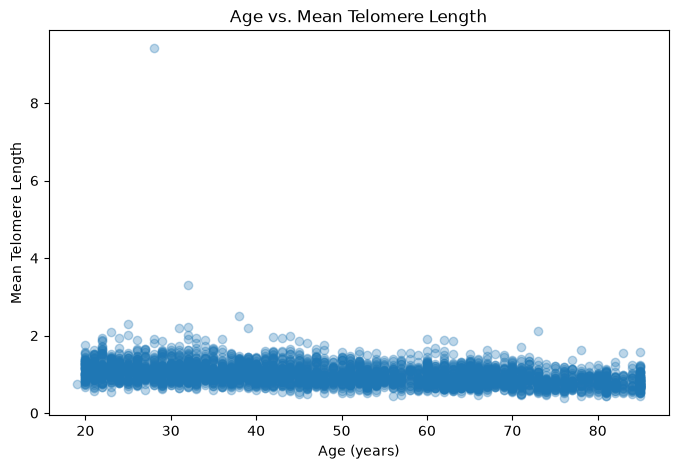

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    data["RIDAGEYR"],
    data["TELOMEAN"],
    alpha=0.3
)

plt.xlabel("Age (years)")
plt.ylabel("Mean Telomere Length")
plt.title("Age vs. Mean Telomere Length")

plt.show()

In [ ]:
# Look at the largest TELOMEAN values

data[["SEQN", "TELOMEAN", "RIDAGEYR"]].sort_values(
    "TELOMEAN",
    ascending=False
).head(20)

,SEQN,TELOMEAN,RIDAGEYR
3569,1378.0,9.420415,28.0
3568,7509.0,3.315313,32.0
3567,9095.0,2.515980,38.0
3566,9170.0,2.310322,25.0
3565,8221.0,2.225661,32.0
3564,8296.0,2.186959,31.0
3563,6444.0,2.186498,39.0
3562,8532.0,2.109059,73.0
3561,8911.0,2.105013,23.0
3560,6133.0,2.021131,25.0


In [ ]:
print(data["TELOMEAN"].describe())

count    3567.000000
mean        0.998350
std         0.296396
min         0.389337
25%         0.807936
50%         0.964025
75%         1.148191
max         9.420415
Name: TELOMEAN, dtype: float64


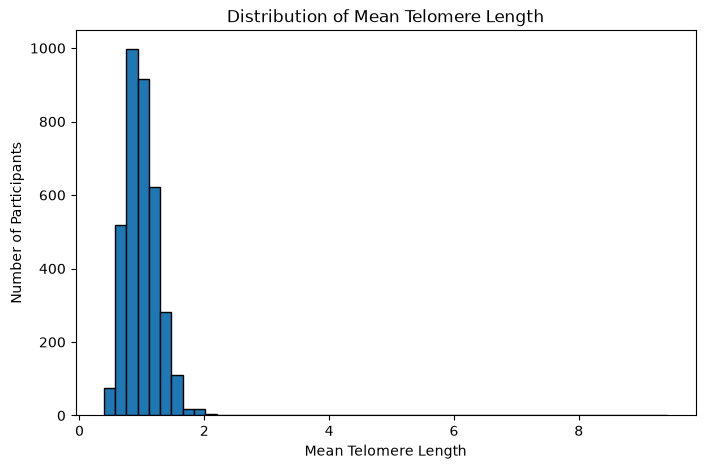

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    data["TELOMEAN"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Mean Telomere Length")
plt.ylabel("Number of Participants")
plt.title("Distribution of Mean Telomere Length")

plt.show()

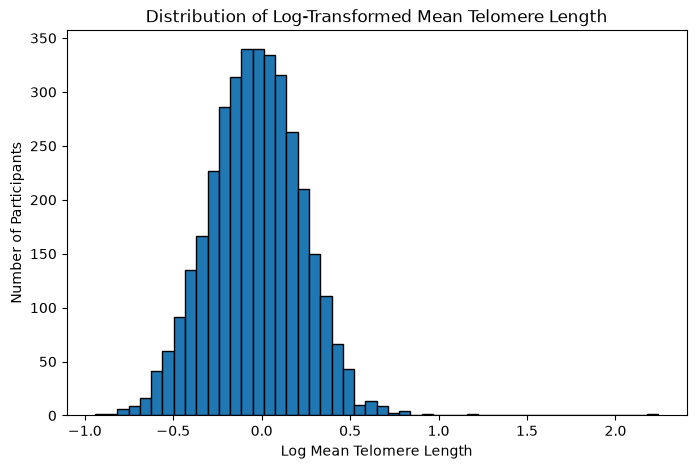

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create log-transformed telomere length
data["log_TELOMEAN"] = np.log(data["TELOMEAN"])

# Plot distribution
plt.figure(figsize=(8, 5))

plt.hist(
    data["log_TELOMEAN"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Log Mean Telomere Length")
plt.ylabel("Number of Participants")
plt.title("Distribution of Log-Transformed Mean Telomere Length")

plt.show()

In [ ]:
# Outcome
y_log = data["log_TELOMEAN"]

# Predictors
X = data[["RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]]

# Cross-validation
results_log = cross_validate(
    model,
    X,
    y_log,
    cv=cv,
    scoring=scoring
)

print("LOG-TRANSFORMED TELOMERE MODEL")
print(f"R²:   {results_log['test_R2'].mean():.3f} ± {results_log['test_R2'].std():.3f}")
print(f"RMSE: {-results_log['test_RMSE'].mean():.3f} ± {results_log['test_RMSE'].std():.3f}")
print(f"MAE:  {-results_log['test_MAE'].mean():.3f} ± {results_log['test_MAE'].std():.3f}")

LOG-TRANSFORMED TELOMERE MODEL
R²:   0.188 ± 0.019
RMSE: 0.233 ± 0.009
MAE:  0.184 ± 0.007


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.regplot(
    data=data,
    x="RIDAGEYR",
    y="log_TELOMEAN",
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"color": "red"}
)

plt.xlabel("Age (years)")
plt.ylabel("Log Mean Telomere Length")
plt.title("Age vs. Log Mean Telomere Length")

plt.show()

ModuleNotFoundError: No module named 'seaborn'

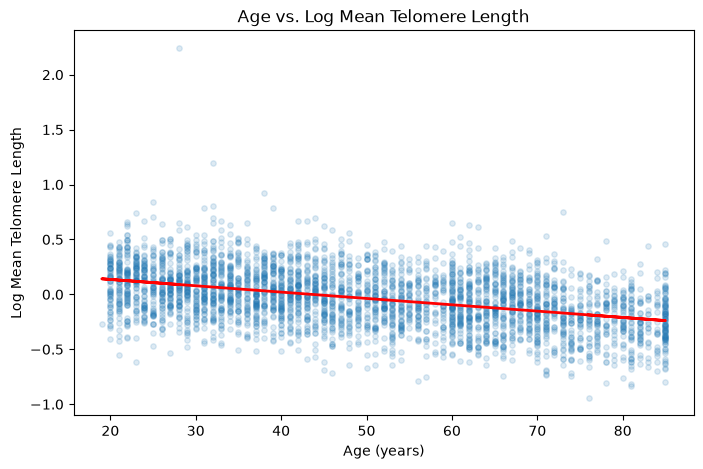

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    data["RIDAGEYR"],
    data["log_TELOMEAN"],
    alpha=0.15,
    s=15
)

# Add a simple linear regression line
z = np.polyfit(
    data["RIDAGEYR"],
    data["log_TELOMEAN"],
    1
)

p = np.poly1d(z)

plt.plot(
    data["RIDAGEYR"],
    p(data["RIDAGEYR"]),
    color="red",
    linewidth=2
)

plt.xlabel("Age (years)")
plt.ylabel("Log Mean Telomere Length")
plt.title("Age vs. Log Mean Telomere Length")

plt.show()

In [ ]:
print("Smoking:")
print(data["SMQ020"].value_counts(dropna=False))

print("\nPhysical activity:")
print(data["PAQ520"].value_counts(dropna=False))

print("\nAlcohol:")
print(data["ALQ100"].value_counts(dropna=False))

Smoking:
SMQ020
2.0    1852
1.0    1706
9.0       6
NaN       3
Name: count, dtype: int64

Physical activity:
PAQ520
3.0    1510
1.0    1388
2.0     625
9.0      42
7.0       2
Name: count, dtype: int64

Alcohol:
ALQ100
1.0    2274
2.0    1115
NaN     176
9.0       2
Name: count, dtype: int64


In [ ]:
import numpy as np
# Make a copy so we don't accidentally change your original dataset
df = data.copy()

# -------------------------
# Clean Smoking
# -------------------------
df["Smoking"] = df["SMQ020"].replace({
    1.0: 1,
    2.0: 0,
    9.0: np.nan
})

# -------------------------
# Clean Physical Activity
# -------------------------
df["Activity"] = df["PAQ520"].replace({
    7.0: np.nan,
    9.0: np.nan
})

# -------------------------
# Clean Alcohol
# -------------------------
df["Alcohol"] = df["ALQ100"].replace({
    1.0: 1,
    2.0: 0,
    9.0: np.nan
})

# Check the results
print("Smoking:")
print(df["Smoking"].value_counts(dropna=False))

print("\nPhysical Activity:")
print(df["Activity"].value_counts(dropna=False))

print("\nAlcohol:")
print(df["Alcohol"].value_counts(dropna=False))

Smoking:
Smoking
0.0    1852
1.0    1706
NaN       9
Name: count, dtype: int64

Physical Activity:
Activity
3.0    1510
1.0    1388
2.0     625
NaN      44
Name: count, dtype: int64

Alcohol:
Alcohol
1.0    2274
0.0    1115
NaN     178
Name: count, dtype: int64


In [ ]:
features_D = ["Age", "Sex", "Race", "BMI"]

features_E = ["Age", "Sex", "Race", "BMI", "Smoking"]

features_F = ["Age", "Sex", "Race", "BMI", "Activity"]

features_G = ["Age", "Sex", "Race", "BMI", "Alcohol"]

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ============================================================
# 1. CREATE CLEAN VARIABLES
# ============================================================

df = data.copy()

# Smoking: 1 = Yes, 2 = No
df["Smoking"] = df["SMQ020"].replace({
    1.0: 1,
    2.0: 0,
    9.0: np.nan
})

# Physical activity
df["Activity"] = df["PAQ520"].replace({
    7.0: np.nan,
    9.0: np.nan
})

# Alcohol: 1 = Yes, 2 = No
df["Alcohol"] = df["ALQ100"].replace({
    1.0: 1,
    2.0: 0,
    9.0: np.nan
})


# ============================================================
# 2. DEFINE THE MODELS WE WANT TO TEST
# ============================================================

feature_sets = {

    "Model D - Age + Sex + Race + BMI":
        ["Age", "Sex", "Race", "BMI"],

    "Model E - D + Smoking":
        ["Age", "Sex", "Race", "BMI", "Smoking"],

    "Model F - D + Activity":
        ["Age", "Sex", "Race", "BMI", "Activity"],

    "Model G - D + Alcohol":
        ["Age", "Sex", "Race", "BMI", "Alcohol"],

    "Model H - Full":
        ["Age", "Sex", "Race", "BMI",
         "Smoking", "Activity", "Alcohol"]
}


# ============================================================
# 3. CHANGE THESE IF YOUR COLUMN NAMES ARE DIFFERENT
# ============================================================

target = "log_TELOMEAN"


# ============================================================
# 4. DEFINE THE ML MODELS
# ============================================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        )
}


# ============================================================
# 5. CROSS-VALIDATION
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 6. RUN EVERYTHING
# ============================================================

for model_name, features in feature_sets.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    # Keep only required columns
    subset = df[features + [target]].copy()

    # Remove rows where target is missing
    subset = subset.dropna(subset=[target])

    X = subset[features]
    y = subset[target]

    # Identify categorical variables
    categorical_features = [
        col for col in features
        if X[col].dtype == "object"
    ]

    numerical_features = [
        col for col in features
        if col not in categorical_features
    ]

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numerical_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        ]
    )

    # Test each ML algorithm
    for algorithm_name, model in models.items():

        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", model)
        ])

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring={
                "R2": "r2",
                "MAE": "neg_mean_absolute_error",
                "RMSE": "neg_root_mean_squared_error"
            }
        )

        r2 = scores["test_R2"]
        mae = -scores["test_MAE"]
        rmse = -scores["test_RMSE"]

        print(f"\n{algorithm_name}")
        print(f"R²:   {r2.mean():.3f} +/- {r2.std():.3f}")
        print(f"MAE:  {mae.mean():.3f} +/- {mae.std():.3f}")
        print(f"RMSE: {rmse.mean():.3f} +/- {rmse.std():.3f}")

    print(f"\nParticipants used: {len(subset)}")


Model D - Age + Sex + Race + BMI


KeyError: "['Age', 'Sex', 'Race', 'BMI'] not in index"

In [ ]:
print(data.columns.tolist())

['SEQN', 'TELOMEAN', 'TELOSTD', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'RIDRETH2', 'DMQMILIT', 'DMDBORN', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDEDUC', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'INDHHINC', 'INDFMINC', 'INDFMPIR', 'RIDEXPRG', 'RIDPREG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBRN', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'WTINT2YR', 'WTINT4YR', 'WTMEC2YR', 'WTMEC4YR', 'SDMVPSU', 'SDMVSTRA', 'SDJ1REPN', 'DMAETHN', 'DMARACE', 'WTMREP01', 'WTMREP02', 'WTMREP03', 'WTMREP04', 'WTMREP05', 'WTMREP06', 'WTMREP07', 'WTMREP08', 'WTMREP09', 'WTMREP10', 'WTMREP11', 'WTMREP12', 'WTMREP13', 'WTMREP14', 'WTMREP15', 'WTMREP16', 'WTMREP17', 'WTMREP18', 'WTMREP19', 'WTMREP20', 'WTMREP21', 'WTMREP22', 'WTMREP23', 'WTMREP24', 'WTMREP25', 'WTMREP26', 'WTMREP27', 'WTMREP28', 'WTMREP29', 'WTMREP30', 'WTMREP31', 'WTMREP32', 'WTMREP33', 'WTMREP34', 'WTMREP35', 'WTMREP36', 'WTMREP37', 'WTMREP38', 'WTMREP39', 'WTMREP40', 'WTMREP41', 'WTMREP42', 'W

In [ ]:
def compare_models(X_train, y_train, label):
    lr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")

    rf = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
    rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")

    gb = GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42)
    gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2")

    print(f"--- {label} ---")
    print(f"Linear Regression CV R²: {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}")
    print(f"Random Forest CV R²:     {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
    print(f"Gradient Boosting CV R²: {gb_cv.mean():.3f} +/- {gb_cv.std():.3f}")
    print()
    

In [ ]:
compare_models(X_train, y_train, "Age only")
compare_models(X2_train, y2_train, "Age + Sex")
compare_models(X3_train, y3_train, "Age + Sex + Race")
compare_models(X4_train, y4_train, "Age + Sex + Race + BMI")
compare_models(Xf_train, yf_train, "Full (all 7 variables)")

NameError: name 'X_train' is not defined

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

DATA_DIR = Path("data")

In [ ]:
telo = pd.read_sas(DATA_DIR / "TELO_A.xpt", format="xport")
demo = pd.read_sas(DATA_DIR / "DEMO.xpt", format="xport")
bmx  = pd.read_sas(DATA_DIR / "BMX.xpt", format="xport")
smq  = pd.read_sas(DATA_DIR / "SMQ.xpt", format="xport")
paq  = pd.read_sas(DATA_DIR / "PAQ.xpt", format="xport")
alq  = pd.read_sas(DATA_DIR / "ALQ.xpt", format="xport")

df = telo.merge(demo, on="SEQN", how="left")
df = df.merge(bmx, on="SEQN", how="left")
df = df.merge(smq, on="SEQN", how="left")
df = df.merge(paq, on="SEQN", how="left")
df = df.merge(alq, on="SEQN", how="left")
df.shape

(3570, 249)

In [ ]:
df_model = df[["SEQN", "TELOMEAN", "RIDAGEYR"]].copy().dropna()
X = df_model[["RIDAGEYR"]]
y = df_model["TELOMEAN"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df_model2 = df[["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR"]].copy().dropna()
df_model2["sex_female"] = (df_model2["RIAGENDR"] == 2).astype(int)
X2 = df_model2[["RIDAGEYR", "sex_female"]]
y2 = df_model2["TELOMEAN"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [ ]:
df_model3 = df[["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1"]].copy().dropna()
df_model3["sex_female"] = (df_model3["RIAGENDR"] == 2).astype(int)
df_model3 = pd.get_dummies(df_model3, columns=["RIDRETH1"], prefix="race", drop_first=True)
race_cols = ["race_2.0", "race_3.0", "race_4.0", "race_5.0"]
X3 = df_model3[["RIDAGEYR", "sex_female"] + race_cols]
y3 = df_model3["TELOMEAN"]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [ ]:
df_model4 = df[["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI"]].copy().dropna()
df_model4["sex_female"] = (df_model4["RIAGENDR"] == 2).astype(int)
df_model4 = pd.get_dummies(df_model4, columns=["RIDRETH1"], prefix="race", drop_first=True)
X4 = df_model4[["RIDAGEYR", "sex_female", "BMXBMI"] + race_cols]
y4 = df_model4["TELOMEAN"]
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

In [ ]:
cols5 = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "SMQ020"]
df_model5 = df[cols5].copy()
df_model5["SMQ020"] = df_model5["SMQ020"].replace([7, 9], np.nan)
df_model5 = df_model5.dropna()
df_model5["sex_female"] = (df_model5["RIAGENDR"] == 2).astype(int)
df_model5 = pd.get_dummies(df_model5, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_model5["ever_smoker"] = (df_model5["SMQ020"] == 1).astype(int)

X5 = df_model5[["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker"] + race_cols]
y5 = df_model5["TELOMEAN"]
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)

In [ ]:
cols6 = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "SMQ020", "PAD020"]
df_model6 = df[cols6].copy()
df_model6["SMQ020"] = df_model6["SMQ020"].replace([7, 9], np.nan)
df_model6["PAD020"] = df_model6["PAD020"].replace([7, 9], np.nan)
df_model6 = df_model6.dropna()
df_model6["sex_female"] = (df_model6["RIAGENDR"] == 2).astype(int)
df_model6 = pd.get_dummies(df_model6, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_model6["ever_smoker"] = (df_model6["SMQ020"] == 1).astype(int)

X6 = df_model6[["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker", "PAD020"] + race_cols]
y6 = df_model6["TELOMEAN"]
X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

In [ ]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "SMQ020", "PAD020", "ALQ120Q"]
df_full = df[cols].copy()
df_full["SMQ020"] = df_full["SMQ020"].replace([7, 9], np.nan)
df_full["PAD020"] = df_full["PAD020"].replace([7, 9], np.nan)
df_full["ALQ120Q"] = df_full["ALQ120Q"].replace([777, 999], np.nan)
df_full = df_full.dropna()
df_full["sex_female"] = (df_full["RIAGENDR"] == 2).astype(int)
df_full = pd.get_dummies(df_full, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_full["ever_smoker"] = (df_full["SMQ020"] == 1).astype(int)
feature_cols = ["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker", "PAD020", "ALQ120Q"] + race_cols
X_full = df_full[feature_cols]
y_full = df_full["TELOMEAN"]
Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

In [ ]:
compare_models(X_train, y_train, "Age only")
compare_models(X2_train, y2_train, "Age + Sex")
compare_models(X3_train, y3_train, "Age + Sex + Race")
compare_models(X4_train, y4_train, "Age + Sex + Race + BMI")
compare_models(X5_train, y5_train, "Age + Sex + Race + BMI + Smoking")
compare_models(X6_train, y6_train, "Age + Sex + Race + BMI + Smoking + Activity")
compare_models(Xf_train, yf_train, "Full (+ Alcohol)")

--- Age only ---
Linear Regression CV R²: 0.141 +/- 0.031
Random Forest CV R²:     0.122 +/- 0.026
Gradient Boosting CV R²: 0.119 +/- 0.026

--- Age + Sex ---
Linear Regression CV R²: 0.139 +/- 0.031
Random Forest CV R²:     0.126 +/- 0.026
Gradient Boosting CV R²: 0.120 +/- 0.025

--- Age + Sex + Race ---
Linear Regression CV R²: 0.151 +/- 0.037
Random Forest CV R²:     0.140 +/- 0.033
Gradient Boosting CV R²: 0.132 +/- 0.031

--- Age + Sex + Race + BMI ---
Linear Regression CV R²: 0.175 +/- 0.007
Random Forest CV R²:     0.165 +/- 0.009
Gradient Boosting CV R²: 0.158 +/- 0.002

--- Age + Sex + Race + BMI + Smoking ---
Linear Regression CV R²: 0.146 +/- 0.054
Random Forest CV R²:     0.130 +/- 0.052
Gradient Boosting CV R²: 0.104 +/- 0.036

--- Age + Sex + Race + BMI + Smoking + Activity ---
Linear Regression CV R²: 0.154 +/- 0.052
Random Forest CV R²:     0.133 +/- 0.040
Gradient Boosting CV R²: 0.109 +/- 0.043

--- Full (+ Alcohol) ---
Linear Regression CV R²: 0.155 +/- 0.055
Random

In [ ]:
rf_final = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
rf_final.fit(Xf_train, yf_train)

importances = pd.Series(rf_final.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
print(importances)

RIDAGEYR       0.729523
BMXBMI         0.122079
race_4.0       0.042568
race_3.0       0.040746
ALQ120Q        0.033247
sex_female     0.013173
PAD020         0.009129
ever_smoker    0.006470
race_2.0       0.003065
race_5.0       0.000000
dtype: float64


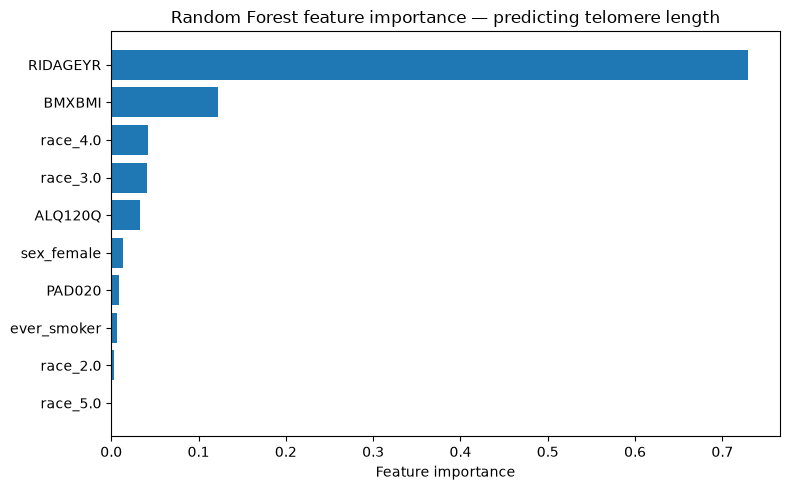

In [ ]:
import matplotlib.pyplot as plt

importances_sorted = importances.sort_values(ascending=True)  # ascending for horizontal bar chart to read top-to-bottom correctly

plt.figure(figsize=(8, 5))
plt.barh(importances_sorted.index, importances_sorted.values)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance — predicting telomere length")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [ ]:
def compare_models(X_train, y_train, label):
    lr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")
    rf = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
    rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
    gb = GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42)
    gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2")

    print(f"--- {label} ---")
    print(f"Linear Regression CV R²: {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}")
    print(f"Random Forest CV R²:     {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
    print(f"Gradient Boosting CV R²: {gb_cv.mean():.3f} +/- {gb_cv.std():.3f}")
    print()

    return {"Stage": label, "Linear Regression": lr_cv.mean(),
            "Random Forest": rf_cv.mean(), "Gradient Boosting": gb_cv.mean()}

--- Age only ---
Linear Regression CV R²: 0.141 +/- 0.031
Random Forest CV R²:     0.122 +/- 0.026
Gradient Boosting CV R²: 0.119 +/- 0.026

--- Age + Sex ---
Linear Regression CV R²: 0.139 +/- 0.031
Random Forest CV R²:     0.126 +/- 0.026
Gradient Boosting CV R²: 0.120 +/- 0.025

--- Age + Sex + Race ---
Linear Regression CV R²: 0.151 +/- 0.037
Random Forest CV R²:     0.140 +/- 0.033
Gradient Boosting CV R²: 0.132 +/- 0.031

--- Age + Sex + Race + BMI ---
Linear Regression CV R²: 0.175 +/- 0.007
Random Forest CV R²:     0.165 +/- 0.009
Gradient Boosting CV R²: 0.158 +/- 0.002

--- + Smoking ---
Linear Regression CV R²: 0.146 +/- 0.054
Random Forest CV R²:     0.130 +/- 0.052
Gradient Boosting CV R²: 0.104 +/- 0.036

--- + Activity ---
Linear Regression CV R²: 0.154 +/- 0.052
Random Forest CV R²:     0.133 +/- 0.040
Gradient Boosting CV R²: 0.109 +/- 0.043

--- + Alcohol (Full) ---
Linear Regression CV R²: 0.155 +/- 0.055
Random Forest CV R²:     0.136 +/- 0.046
Gradient Boosting CV 

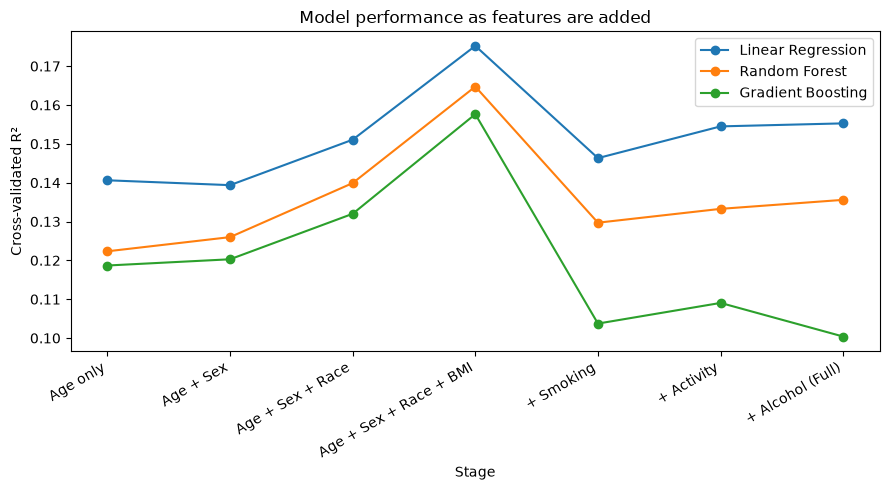

,Linear Regression,Random Forest,Gradient Boosting
Stage,,,
Age only,0.140613,0.122333,0.118675
Age + Sex,0.139362,0.125983,0.120279
Age + Sex + Race,0.151060,0.139895,0.131987
Age + Sex + Race + BMI,0.175216,0.164732,0.157631
+ Smoking,0.146320,0.129698,0.103730
+ Activity,0.154489,0.133260,0.109045
+ Alcohol (Full),0.155265,0.135577,0.100388


In [ ]:
results = []
results.append(compare_models(X_train, y_train, "Age only"))
results.append(compare_models(X2_train, y2_train, "Age + Sex"))
results.append(compare_models(X3_train, y3_train, "Age + Sex + Race"))
results.append(compare_models(X4_train, y4_train, "Age + Sex + Race + BMI"))
results.append(compare_models(X5_train, y5_train, "+ Smoking"))
results.append(compare_models(X6_train, y6_train, "+ Activity"))
results.append(compare_models(Xf_train, yf_train, "+ Alcohol (Full)"))

results_df = pd.DataFrame(results).set_index("Stage")

results_df.plot(kind="line", marker="o", figsize=(9, 5))
plt.ylabel("Cross-validated R²")
plt.title("Model performance as features are added")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=150)
plt.show()

results_df

In [29]:
telo_b = pd.read_sas(DATA_DIR / "TELO_B.xpt", format="xport")
demo_b = pd.read_sas(DATA_DIR / "DEMO_B.xpt", format="xport")
bmx_b  = pd.read_sas(DATA_DIR / "BMX_B.xpt", format="xport")
smq_b  = pd.read_sas(DATA_DIR / "SMQ_B.xpt", format="xport")
paq_b  = pd.read_sas(DATA_DIR / "PAQ_B.xpt", format="xport")
alq_b  = pd.read_sas(DATA_DIR / "ALQ_B.xpt", format="xport")

In [31]:
df_b = telo_b.merge(demo_b, on="SEQN", how="left")
df_b = df_b.merge(bmx_b, on="SEQN", how="left")
df_b = df_b.merge(smq_b, on="SEQN", how="left")
df_b = df_b.merge(paq_b, on="SEQN", how="left")
df_b = df_b.merge(alq_b, on="SEQN", how="left")
df_b.shape

(4269, 133)

In [32]:
df["cycle"] = "1999-2000"
df_b["cycle"] = "2001-2002"

df_combined = pd.concat([df, df_b], ignore_index=True)
df_combined.shape

(7839, 257)

In [33]:
cols = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI",
        "SMQ020", "PAD020", "ALQ120Q", "cycle"]
df_combined_model = df_combined[cols].copy()

# recode NHANES special/missing codes to NaN
df_combined_model["SMQ020"] = df_combined_model["SMQ020"].replace([7, 9], np.nan)
df_combined_model["PAD020"] = df_combined_model["PAD020"].replace([7, 9], np.nan)
df_combined_model["ALQ120Q"] = df_combined_model["ALQ120Q"].replace([777, 999], np.nan)

df_combined_model = df_combined_model.dropna()

# encode categoricals
df_combined_model["sex_female"] = (df_combined_model["RIAGENDR"] == 2).astype(int)
df_combined_model = pd.get_dummies(df_combined_model, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_combined_model["ever_smoker"] = (df_combined_model["SMQ020"] == 1).astype(int)
df_combined_model["cycle_2001"] = (df_combined_model["cycle"] == "2001-2002").astype(int)

df_combined_model.shape

(6111, 16)

In [34]:
race_cols_combined = [c for c in df_combined_model.columns if c.startswith("race_")]
feature_cols_combined = ["RIDAGEYR", "sex_female", "BMXBMI", "ever_smoker", "PAD020", "ALQ120Q", "cycle_2001"] + race_cols_combined

X_combined = df_combined_model[feature_cols_combined]
y_combined = df_combined_model["TELOMEAN"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42
)

print("Training rows:", Xc_train.shape[0])
print("Testing rows:", Xc_test.shape[0])

Training rows: 4888
Testing rows: 1223


In [35]:
compare_models(Xc_train, yc_train, "Combined 1999-2002 (Full + Cycle)")

--- Combined 1999-2002 (Full + Cycle) ---
Linear Regression CV R²: 0.160 +/- 0.041
Random Forest CV R²:     0.141 +/- 0.033
Gradient Boosting CV R²: 0.140 +/- 0.034



In [36]:
rf_combined = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
rf_combined.fit(Xc_train, yc_train)

importances_combined = pd.Series(rf_combined.feature_importances_, index=feature_cols_combined)
importances_combined = importances_combined.sort_values(ascending=False)
print(importances_combined)

RIDAGEYR       0.746778
BMXBMI         0.105849
cycle_2001     0.045124
race_4.0       0.028465
ALQ120Q        0.024143
sex_female     0.020756
race_3.0       0.012371
PAD020         0.007966
ever_smoker    0.006765
race_2.0       0.001719
race_5.0       0.000065
dtype: float64


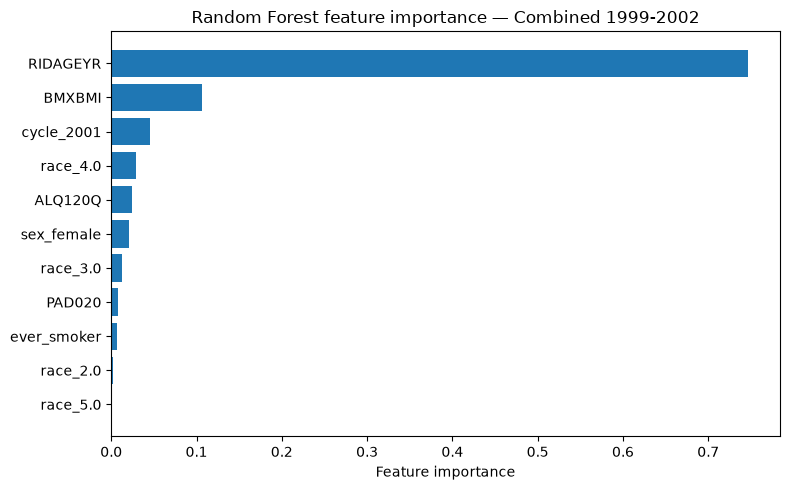

In [37]:
importances_combined_sorted = importances_combined.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances_combined_sorted.index, importances_combined_sorted.values)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance — Combined 1999-2002")
plt.tight_layout()
plt.savefig("feature_importance_combined.png", dpi=150)
plt.show()

In [38]:
cols_simple = ["SEQN", "TELOMEAN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "BMXBMI", "cycle"]
df_simple = df_combined[cols_simple].copy()
df_simple = df_simple.dropna()

df_simple["sex_female"] = (df_simple["RIAGENDR"] == 2).astype(int)
df_simple = pd.get_dummies(df_simple, columns=["RIDRETH1"], prefix="race", drop_first=True)
df_simple["cycle_2001"] = (df_simple["cycle"] == "2001-2002").astype(int)

df_simple.shape

(7578, 12)

In [40]:
race_cols_simple = [c for c in df_simple.columns if c.startswith("race_")]
feature_cols_simple = ["RIDAGEYR", "sex_female", "BMXBMI", "cycle_2001"] + race_cols_simple

X_simple = df_simple[feature_cols_simple]
y_simple = df_simple["TELOMEAN"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

compare_models(Xs_train, ys_train, "Simplified: Age+Sex+Race+BMI+Cycle")

--- Simplified: Age+Sex+Race+BMI+Cycle ---
Linear Regression CV R²: 0.178 +/- 0.031
Random Forest CV R²:     0.168 +/- 0.027
Gradient Boosting CV R²: 0.166 +/- 0.025



In [42]:
lr_simple = LinearRegression()
lr_simple.fit(Xs_train, ys_train)

rf_simple = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42)
rf_simple.fit(Xs_train, ys_train)

gb_simple = GradientBoostingRegressor(max_depth=3, min_samples_leaf=20, learning_rate=0.05, n_estimators=200, random_state=42)
gb_simple.fit(Xs_train, ys_train);


In [43]:
def predict_telomere():
    print("=== Telomere Length Predictor ===")
    print("(based on age, sex, race/ethnicity, and BMI)\n")

    age = float(input("Age (years): "))
    weight_kg = float(input("Weight (kg): "))
    height_cm = float(input("Height (cm): "))
    bmi = weight_kg / ((height_cm / 100) ** 2)
    print(f"Calculated BMI: {bmi:.1f}")

    sex_input = input("Sex (M/F): ").strip().upper()
    sex_female = 1 if sex_input == "F" else 0

    print("\nRace/ethnicity (NHANES categories):")
    print("1) Mexican American  2) Other Hispanic  3) Non-Hispanic White  4) Non-Hispanic Black  5) Other/Multiracial")
    race_input = input("Enter 1-5: ")

    row = {
        "RIDAGEYR": age,
        "sex_female": sex_female,
        "BMXBMI": bmi,
        "cycle_2001": 0,
        "race_2.0": 1 if race_input == "2" else 0,
        "race_3.0": 1 if race_input == "3" else 0,
        "race_4.0": 1 if race_input == "4" else 0,
        "race_5.0": 1 if race_input == "5" else 0,
    }
    input_df = pd.DataFrame([row])[feature_cols_simple]

    prediction = lr_simple.predict(input_df)[0]
    print(f"\nPredicted TELOMEAN (T/S ratio): {prediction:.3f}")
    print("(Linear Regression was used — your best-performing model, R² ≈ 0.178)")

predict_telomere()

=== Telomere Length Predictor ===
(based on age, sex, race/ethnicity, and BMI)



ValueError: could not convert string to float: ''

In [44]:
def predict_telomere(model, age, weight_kg, height_cm, sex, race):
    bmi = weight_kg / ((height_cm / 100) ** 2)

    sex_female = 1 if sex.upper() == "F" else 0

    row = {
        "RIDAGEYR": age,
        "sex_female": sex_female,
        "BMXBMI": bmi,
        "cycle_2001": 0,
        "race_2.0": 1 if race == 2 else 0,
        "race_3.0": 1 if race == 3 else 0,
        "race_4.0": 1 if race == 4 else 0,
        "race_5.0": 1 if race == 5 else 0,
    }
    input_df = pd.DataFrame([row])[feature_cols_simple]

    prediction = model.predict(input_df)[0]
    return prediction

In [45]:
person = {"age": 30, "weight_kg": 65, "height_cm": 165, "sex": "F", "race": 3}

print("Linear Regression:", predict_telomere(lr_simple, **person))
print("Random Forest:    ", predict_telomere(rf_simple, **person))
print("Gradient Boosting:", predict_telomere(gb_simple, **person))

Linear Regression: 1.1478943602526857
Random Forest:     1.1279340369428132
Gradient Boosting: 1.1369408786900916


In [46]:
sample_test = Xs_test.head(5).copy()
sample_test["Actual_TELOMEAN"] = ys_test.head(5)
sample_test["Predicted_LR"] = lr_simple.predict(Xs_test.head(5))
sample_test["Predicted_RF"] = rf_simple.predict(Xs_test.head(5))
sample_test["Predicted_GB"] = gb_simple.predict(Xs_test.head(5))

sample_test[["RIDAGEYR", "BMXBMI", "Actual_TELOMEAN", "Predicted_LR", "Predicted_RF", "Predicted_GB"]]


,RIDAGEYR,BMXBMI,Actual_TELOMEAN,Predicted_LR,Predicted_RF,Predicted_GB
792,71.0,17.80,0.791670,0.920988,0.926868,0.963078
660,64.0,26.80,0.763890,0.895854,0.949514,0.926793
899,47.0,26.15,0.808974,1.017196,1.076050,1.038869
4481,72.0,21.23,0.844509,0.949459,0.948374,0.961447
7246,53.0,34.13,1.314077,1.074230,1.068938,1.093126


In [47]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_cv = cross_val_score(Ridge(alpha=1.0), Xs_train, ys_train, cv=5, scoring="r2")
lasso_cv = cross_val_score(Lasso(alpha=0.01), Xs_train, ys_train, cv=5, scoring="r2")
elastic_cv = cross_val_score(ElasticNet(alpha=0.01, l1_ratio=0.5), Xs_train, ys_train, cv=5, scoring="r2")

print("Ridge CV R²:      ", ridge_cv.mean(), "+/-", ridge_cv.std())
print("Lasso CV R²:      ", lasso_cv.mean(), "+/-", lasso_cv.std())
print("ElasticNet CV R²: ", elastic_cv.mean(), "+/-", elastic_cv.std())

Ridge CV R²:       0.17813755894335317 +/- 0.030753024011363237
Lasso CV R²:       0.16080740893947582 +/- 0.02713429170621313
ElasticNet CV R²:  0.16866303036515204 +/- 0.02840225370085303
